# Home task: recommendation systems

## Home Task: Simple Recommender System

In this task we replicate a simple movie recommender system.  
The main idea is to recommend movies using a weighted rating formula, where both average rating and number of votes are taken into account.

## Import libraries


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load the data


In [15]:
# load movies dataset
df = pd.read_csv('tmdb_5000_movies.csv')

# show first rows
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


## Check dataset information


In [16]:
print('df.shape=', df.shape)
print(df.columns)

df.shape= (4803, 20)
Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')


## select main columns for recommender


In [17]:
df_movies = df[['title', 'vote_average', 'vote_count', 'popularity']]

df_movies.head()

,title,vote_average,vote_count,popularity
0,Avatar,7.2,11800,150.437577
1,Pirates of the Caribbean: At World's End,6.9,4500,139.082615
2,Spectre,6.3,4466,107.376788
3,The Dark Knight Rises,7.6,9106,112.312950
4,John Carter,6.1,2124,43.926995


## Check missing values


In [18]:
df_movies.isnull().sum()

title           0
vote_average    0
vote_count      0
popularity      0
dtype: int64

## Calculate mean rating

C is the mean vote across all movies.  

In [19]:
# mean rating for all movies
C = df_movies['vote_average'].mean()

print('C=', C)

C= 6.092171559442016


## Calculate minimum number of votes

m is the minimum number of votes required to be listed.  

In [20]:
# minimum number of votes required
m = df_movies['vote_count'].quantile(0.90)

print('m=', m)

m= 1838.4000000000015


## Filter qualified movies

Now we keep only movies that have vote_count greater than or equal to m.

In [21]:
df_qualified = df_movies.copy()
df_qualified = df_qualified[df_qualified['vote_count'] >= m]

print('df_qualified.shape=', df_qualified.shape)
df_qualified.head()

df_qualified.shape= (481, 4)


,title,vote_average,vote_count,popularity
0,Avatar,7.2,11800,150.437577
1,Pirates of the Caribbean: At World's End,6.9,4500,139.082615
2,Spectre,6.3,4466,107.376788
3,The Dark Knight Rises,7.6,9106,112.312950
4,John Carter,6.1,2124,43.926995


## Weighted rating formula

Formula:

WR = (v / (v + m)) * R + (m / (v + m)) * C

where:
- v is number of votes for the movie
- m is minimum votes required
- R is average rating of the movie
- C is mean rating across all movies

In [22]:
def weighted_rating(x, m=m, C=C):
    # number of votes
    v = x['vote_count']
    
    # average rating
    R = x['vote_average']
    
    # weighted rating formula
    return (v / (v + m)) * R + (m / (v + m)) * C

## Apply weighted rating


In [24]:
# calculate score for each movie
df_qualified['score'] = df_qualified.apply(weighted_rating, axis=1)

df_qualified.head()

,title,vote_average,vote_count,popularity,score
0,Avatar,7.2,11800,150.437577,7.050669
1,Pirates of the Caribbean: At World's End,6.9,4500,139.082615,6.665696
2,Spectre,6.3,4466,107.376788,6.239396
3,The Dark Knight Rises,7.6,9106,112.312950,7.346721
4,John Carter,6.1,2124,43.926995,6.096368


## Sort movies by score


In [27]:
df_recommend = df_qualified.sort_values('score', ascending=False)

df_recommend[['title', 'vote_count', 'vote_average', 'score']].head(10)

,title,vote_count,vote_average,score
1881,The Shawshank Redemption,8205,8.5,8.059258
662,Fight Club,9413,8.3,7.939256
65,The Dark Knight,12002,8.2,7.920020
3232,Pulp Fiction,8428,8.3,7.904645
96,Inception,13752,8.1,7.863239
3337,The Godfather,5893,8.4,7.851236
95,Interstellar,10867,8.1,7.809479
809,Forrest Gump,7927,8.2,7.803188
329,The Lord of the Rings: The Return of the King,8064,8.1,7.727243
1990,The Empire Strikes Back,5879,8.2,7.697884


## Top 15 recommended movies


In [28]:
top_movies = df_recommend[['title', 'vote_count', 'vote_average', 'score']].head(15)

top_movies

,title,vote_count,vote_average,score
1881,The Shawshank Redemption,8205,8.5,8.059258
662,Fight Club,9413,8.3,7.939256
65,The Dark Knight,12002,8.2,7.920020
3232,Pulp Fiction,8428,8.3,7.904645
96,Inception,13752,8.1,7.863239
3337,The Godfather,5893,8.4,7.851236
95,Interstellar,10867,8.1,7.809479
809,Forrest Gump,7927,8.2,7.803188
329,The Lord of the Rings: The Return of the King,8064,8.1,7.727243
1990,The Empire Strikes Back,5879,8.2,7.697884


## Visualize top movies


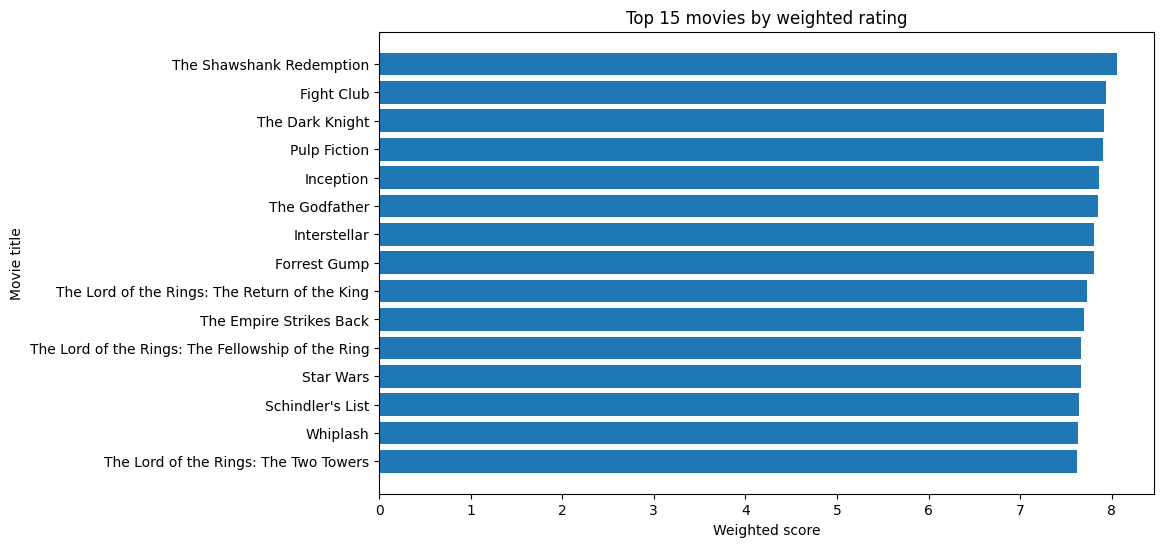

In [29]:
plt.figure(figsize=(10, 6))

plt.barh(top_movies['title'], top_movies['score'])
plt.xlabel('Weighted score')
plt.ylabel('Movie title')
plt.title('Top 15 movies by weighted rating')

plt.gca().invert_yaxis()
plt.show()

## Optional: Content-Based Recommender

In this part we build a simple content-based recommender.  
It recommends movies that are similar to a selected movie based on the movie overview text.

## Import tools

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

## Prepare movie overviews


In [31]:
# replace missing overviews
df['overview'] = df['overview'].fillna('')

df[['title', 'overview']].head()

,title,overview
0,Avatar,"In the 22nd century, a paraplegic Marine is di..."
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha..."
2,Spectre,A cryptic message from Bond’s past sends him o...
3,The Dark Knight Rises,Following the death of District Attorney Harve...
4,John Carter,"John Carter is a war-weary, former military ca..."


## Create TF-IDF matrix


In [32]:
tfidf = TfidfVectorizer(stop_words='english')

# create tf-idf matrix
tfidf_matrix = tfidf.fit_transform(df['overview'])

print('tfidf_matrix.shape=', tfidf_matrix.shape)

tfidf_matrix.shape= (4803, 20978)


## Calculate cosine similarity


In [33]:
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

print('cosine_sim.shape=', cosine_sim.shape)

cosine_sim.shape= (4803, 4803)


## Create movie index


In [34]:
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

indices.head()

title
Avatar                                      0
Pirates of the Caribbean: At World's End    1
Spectre                                     2
The Dark Knight Rises                       3
John Carter                                 4
dtype: int64

## Recommendation function


In [35]:
def get_recommendations(title, cosine_sim=cosine_sim):
    # get index of movie
    idx = indices[title]
    
    # get similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    # sort movies by similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # take top 10 similar movies, excluding the same movie
    sim_scores = sim_scores[1:11]
    
    # get movie indexes
    movie_indices = [i[0] for i in sim_scores]
    
    # return movie titles
    return df['title'].iloc[movie_indices]

## Test content-based recommender


In [36]:
get_recommendations('The Dark Knight Rises')

65                              The Dark Knight
299                              Batman Forever
428                              Batman Returns
1359                                     Batman
3854    Batman: The Dark Knight Returns, Part 2
119                               Batman Begins
2507                                  Slow Burn
9            Batman v Superman: Dawn of Justice
1181                                        JFK
210                              Batman & Robin
Name: title, dtype: object

## Another test


In [37]:
get_recommendations('Avatar')

3604                       Apollo 18
2130                    The American
634                       The Matrix
1341            The Inhabited Island
529                 Tears of the Sun
1610                           Hanna
311     The Adventures of Pluto Nash
847                         Semi-Pro
775                        Supernova
2628             Blood and Chocolate
Name: title, dtype: object